<center><h1>Hou_Tianbo_HW3</h1></center>
<br>

Name: Tianbo Hou
<br>
Github Username: houdan-hub
<br>
USC ID: 8943381210



## 1. Time Series Classification Part 1: Feature Creation/Extraction

### (a) Download Data

The AReM data was downloaded from the UCI repository
(Activity Recognition system based on Multisensor data fusion).
It contains 7 activity folders (bending1, bending2, cycling, lying, sitting, standing, walking).
Each folder contains multiple CSV files; each file is one instance (one time series recording) with
6 sensor series of 480 values each.

Package imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import OLSInfluence
from scipy import stats
from sklearn.feature_selection import f_classif

pd.set_option('display.width', 150)
pd.set_option('display.max_columns', 50)
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')

Get the AReM Data Set

In [2]:
# Load the data with a relative path.
DATA_ROOT = 'data/AReM'
SERIES_NAMES = ['avg_rss12', 'var_rss12', 'avg_rss13', 'var_rss13', 'avg_rss23', 'var_rss23']
ALL_COLS = ['time'] + SERIES_NAMES

# Robust parser: a few AReM files have formatting quirks -
#  - bending2/dataset4.csv is space-separated instead of comma-separated
#  - cycling/dataset9.csv and dataset14.csv have a trailing comma on the last row
#  - sitting/dataset8.csv has one missing row (479 values instead of 480)
def read_arem_file(path):
    rows = []
    with open(path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('#'):
                continue
            parts = line.split(',')
            if len(parts) < 7:
                parts = line.split()
            parts = [p for p in parts if p != '']   # drop empty fields (trailing comma)
            try:
                vals = [float(p) for p in parts[:7]]
            except ValueError:
                continue
            rows.append(vals)
    return np.array(rows)

records = []
activity_order = []
short_series = []
for folder in sorted(os.listdir(DATA_ROOT)):
    fpath = os.path.join(DATA_ROOT, folder)
    if not os.path.isdir(fpath):
        continue
    for fname in sorted(os.listdir(fpath)):
        if not fname.endswith('.csv'):
            continue
        mat = read_arem_file(os.path.join(fpath, fname))
        if mat.shape[0] != 480:
            short_series.append((folder, fname, mat.shape[0]))
        series = mat[:, 1:7].astype(float)   # drop the time column, keep 6 sensor series
        records.append({'activity': folder, 'file': fname, 'series': series})
        activity_order.append(folder)

print('Total instances:', len(records))
print('Each instance: 6 time series x', records[0]['series'].shape[1], 'values')
print('Activities:', sorted(set(activity_order)))
print()
print('Files with an anomalous number of rows (still usable, noted here):')
for t in short_series:
    print(' ', t)

Total instances: 88
Each instance: 6 time series x 6 values
Activities: ['bending1', 'bending2', 'cycling', 'lying', 'sitting', 'standing', 'walking']

Files with an anomalous number of rows (still usable, noted here):
  ('sitting', 'dataset8.csv', 479)


### (b) Test and Train Data

In [3]:
# Rule: keep dataset1/2 of bending1, bending2 as test, and dataset1/2/3 of all other
# folders as test; everything else is training.
TEST_RULE = {}
for folder in sorted(set(activity_order)):
    if folder.startswith('bending'):
        TEST_RULE[folder] = {1, 2}
    else:
        TEST_RULE[folder] = {1, 2, 3}

train_records, test_records = [], []
for r in records:
    num = int(r['file'].replace('dataset', '').replace('.csv', ''))
    if num in TEST_RULE[r['activity']]:
        test_records.append(r)
    else:
        train_records.append(r)

print('Train instances:', len(train_records))
print('Test instances :', len(test_records))
print()
print('Test set composition:')
for folder in sorted({r['activity'] for r in test_records}):
    n_test = sum(1 for r in test_records if r['activity'] == folder)
    n_all = sum(1 for r in records if r['activity'] == folder)
    print(f'  {folder}: test {n_test}/{n_all}')

Train instances: 69
Test instances : 19

Test set composition:
  bending1: test 2/7
  bending2: test 2/6
  cycling: test 3/15
  lying: test 3/15
  sitting: test 3/15
  standing: test 3/15
  walking: test 3/15


### (c) Feature Extraction

#### i. Research

Common time-domain features used in time series classification include:

- minimum, maximum (extreme values)
- mean, median (central tendency)
- standard deviation, variance (spread)
- first and third quartiles, interquartile range (percentiles / spread)
- root mean square (RMS)
- skewness, kurtosis (shape)
- energy (sum of squares), total sum
- zero-crossing rate (frequency content proxy)
- mean absolute deviation, peak-to-peak amplitude
- autocorrelation, slope / trend of the series

In this assignment we extract the seven requested features for each of the six series:
minimum, maximum, mean, median, standard deviation, first quartile, third quartile.

#### ii. Extraction

For each instance and each of its 6 time series we compute 7 features, giving
7 x 6 = 42 features per instance. Column naming: `min_1` means the minimum of the
first time series, `q3_6` means the third quartile of the sixth time series.
Series order: 1=avg_rss12, 2=var_rss12, 3=avg_rss13, 4=var_rss13, 5=avg_rss23, 6=var_rss23.

In [4]:
feature_names = ['min', 'max', 'mean', 'median', 'std', 'q1', 'q3']

def extract_features(rec):
    feats = []
    for s in range(rec['series'].shape[1]):
        x = rec['series'][:, s]
        feats += [x.min(), x.max(), x.mean(), np.median(x), x.std(),
                  np.percentile(x, 25), np.percentile(x, 75)]
    return feats

cols = [f'{fn}_{i}' for i in range(1, 7) for fn in feature_names]

X_all = pd.DataFrame([extract_features(r) for r in records], columns=cols)
X_all.index = np.arange(1, len(records) + 1)
X_all.index.name = 'Instance'
X_all.insert(0, 'activity', [r['activity'] for r in records])

print('Feature matrix shape:', X_all.shape)
print()
X_all.head(10)

Feature matrix shape: (88, 43)



,activity,min_1,max_1,mean_1,median_1,std_1,q1_1,q3_1,min_2,max_2,mean_2,median_2,std_2,q1_2,q3_2,min_3,max_3,mean_3,median_3,std_3,q1_3,q3_3,min_4,max_4,mean_4,median_4,std_4,q1_4,q3_4,min_5,max_5,mean_5,median_5,std_5,q1_5,q3_5,min_6,max_6,mean_6,median_6,std_6,q1_6,q3_6
Instance,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,bending1,37.25,45.00,40.624792,40.50,1.475428,39.2500,42.00,0.0,1.30,0.358604,0.43,0.322269,0.00,0.5000,4.00,29.50,19.040937,19.250,4.458301,16.00,23.2500,0.0,7.23,0.832542,0.50,0.964652,0.00,1.120,27.25,38.25,34.311292,35.000,2.186168,33.0000,36.00,0.0,1.92,0.570583,0.43,0.582308,0.00,1.30
2,bending1,38.00,45.67,42.812812,42.50,1.434054,42.0000,43.67,0.0,1.22,0.372437,0.47,0.288857,0.00,0.5000,2.00,29.50,20.096979,21.000,3.889679,19.00,22.2500,0.0,5.76,0.876438,0.50,1.046167,0.00,1.145,27.67,38.50,33.024583,33.000,1.993175,32.0000,34.50,0.0,3.11,0.571083,0.43,0.600383,0.00,1.30
3,bending1,35.00,47.40,43.954500,44.33,1.557210,43.0000,45.00,0.0,1.70,0.426250,0.47,0.338337,0.00,0.5000,6.50,29.75,22.122354,23.000,3.027784,19.75,24.0000,0.0,4.44,0.497312,0.43,0.550083,0.00,0.830,29.00,38.50,35.588458,36.000,1.997520,35.3625,36.50,0.0,1.79,0.493292,0.43,0.512971,0.00,0.94
4,bending1,33.00,47.75,42.179812,43.50,3.666840,39.1500,45.00,0.0,3.00,0.696042,0.50,0.630203,0.00,1.1200,8.50,30.00,22.183625,23.000,3.806498,20.50,24.3725,0.0,5.15,0.989917,0.83,0.952736,0.43,1.300,20.00,38.67,33.493917,35.000,3.845436,30.4575,36.33,0.0,2.18,0.613521,0.50,0.523771,0.00,1.00
5,bending1,33.00,45.75,41.678063,41.75,2.241152,41.3300,42.75,0.0,2.83,0.535979,0.50,0.405046,0.43,0.7100,3.00,28.25,19.006563,19.125,4.082847,16.50,22.0625,0.0,6.42,0.841875,0.50,0.927833,0.43,1.120,23.67,37.50,29.857083,30.000,2.408514,28.4575,31.25,0.0,1.79,0.383292,0.43,0.388759,0.00,0.50
6,bending1,37.00,48.00,43.454958,43.25,1.384653,42.5000,45.00,0.0,1.58,0.378083,0.47,0.315237,0.00,0.5000,5.75,27.00,15.793333,15.000,3.843628,13.00,18.2700,0.0,10.03,0.849354,0.50,0.994724,0.43,1.120,8.00,33.50,23.034792,23.500,2.486268,22.2500,24.00,0.0,5.26,0.679646,0.50,0.621885,0.43,0.87
7,bending1,36.25,48.00,43.969125,44.50,1.616677,43.3100,44.67,0.0,1.50,0.413125,0.47,0.262837,0.43,0.5000,1.50,26.33,15.868021,16.250,3.738520,14.25,18.0000,0.0,5.17,0.666354,0.47,0.788162,0.00,0.940,11.33,30.75,22.103750,21.670,3.314843,20.5000,23.75,0.0,2.96,0.555312,0.49,0.487318,0.00,0.83
8,bending2,12.75,51.00,24.562958,24.25,3.733619,23.1875,26.50,0.0,6.87,0.590833,0.43,0.836535,0.00,0.7100,0.00,25.33,19.121333,20.250,4.295131,18.00,22.0000,0.0,6.76,0.736771,0.47,0.926081,0.00,0.870,10.67,30.00,23.493042,23.750,3.689936,20.5000,27.00,0.0,4.97,0.700188,0.50,0.692997,0.43,0.87
9,bending2,0.00,42.75,27.464604,28.00,3.579847,25.5000,30.00,0.0,7.76,0.449708,0.43,0.766397,0.00,0.5000,7.50,35.00,20.842542,20.750,3.822280,18.00,22.5000,0.0,5.76,0.779917,0.50,0.903493,0.00,0.940,0.00,33.00,17.617938,18.000,5.048375,15.0000,20.75,0.0,6.76,1.122125,0.83,1.011287,0.47,1.30


In [5]:
X_all.round(4)

,activity,min_1,max_1,mean_1,median_1,std_1,q1_1,q3_1,min_2,max_2,mean_2,median_2,std_2,q1_2,q3_2,min_3,max_3,mean_3,median_3,std_3,q1_3,q3_3,min_4,max_4,mean_4,median_4,std_4,q1_4,q3_4,min_5,max_5,mean_5,median_5,std_5,q1_5,q3_5,min_6,max_6,mean_6,median_6,std_6,q1_6,q3_6
Instance,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,bending1,37.25,45.00,40.6248,40.500,1.4754,39.25,42.0000,0.0,1.30,0.3586,0.430,0.3223,0.00,0.5000,4.00,29.50,19.0409,19.250,4.4583,16.00,23.2500,0.0,7.23,0.8325,0.500,0.9647,0.0000,1.1200,27.25,38.25,34.3113,35.00,2.1862,33.0000,36.00,0.0,1.92,0.5706,0.430,0.5823,0.00,1.3000
2,bending1,38.00,45.67,42.8128,42.500,1.4341,42.00,43.6700,0.0,1.22,0.3724,0.470,0.2889,0.00,0.5000,2.00,29.50,20.0970,21.000,3.8897,19.00,22.2500,0.0,5.76,0.8764,0.500,1.0462,0.0000,1.1450,27.67,38.50,33.0246,33.00,1.9932,32.0000,34.50,0.0,3.11,0.5711,0.430,0.6004,0.00,1.3000
3,bending1,35.00,47.40,43.9545,44.330,1.5572,43.00,45.0000,0.0,1.70,0.4263,0.470,0.3383,0.00,0.5000,6.50,29.75,22.1224,23.000,3.0278,19.75,24.0000,0.0,4.44,0.4973,0.430,0.5501,0.0000,0.8300,29.00,38.50,35.5885,36.00,1.9975,35.3625,36.50,0.0,1.79,0.4933,0.430,0.5130,0.00,0.9400
4,bending1,33.00,47.75,42.1798,43.500,3.6668,39.15,45.0000,0.0,3.00,0.6960,0.500,0.6302,0.00,1.1200,8.50,30.00,22.1836,23.000,3.8065,20.50,24.3725,0.0,5.15,0.9899,0.830,0.9527,0.4300,1.3000,20.00,38.67,33.4939,35.00,3.8454,30.4575,36.33,0.0,2.18,0.6135,0.500,0.5238,0.00,1.0000
5,bending1,33.00,45.75,41.6781,41.750,2.2412,41.33,42.7500,0.0,2.83,0.5360,0.500,0.4050,0.43,0.7100,3.00,28.25,19.0066,19.125,4.0828,16.50,22.0625,0.0,6.42,0.8419,0.500,0.9278,0.4300,1.1200,23.67,37.50,29.8571,30.00,2.4085,28.4575,31.25,0.0,1.79,0.3833,0.430,0.3888,0.00,0.5000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,walking,20.75,46.25,34.7633,35.290,4.7373,31.67,38.2500,0.0,12.68,4.2238,3.900,2.2756,2.49,5.7225,5.00,23.75,15.2390,15.330,2.9178,13.50,17.2500,0.0,9.20,3.2071,3.000,1.5888,2.0500,4.1950,6.00,25.50,16.2996,16.25,3.1714,14.2500,18.33,0.0,9.39,3.2883,3.270,1.6458,2.05,4.3050
85,walking,21.50,51.00,34.9358,35.500,4.6411,32.00,38.0625,0.0,12.21,4.1158,3.845,2.3328,2.35,5.6250,6.50,23.33,15.5245,15.500,2.8972,13.33,17.6700,0.0,9.09,3.0928,2.870,1.5019,2.0575,3.8400,6.33,25.00,15.9972,16.25,3.1887,14.2375,18.25,0.0,10.21,3.2800,3.015,1.6991,2.12,4.5000
86,walking,18.33,47.67,34.3330,34.750,4.9436,31.25,38.0000,0.0,12.48,4.3970,3.900,2.5660,2.49,5.7450,7.67,23.33,15.5629,15.500,2.9646,13.67,17.5000,0.0,9.01,3.1983,2.930,1.6745,2.0500,4.2450,6.67,24.00,15.8644,16.00,2.9974,13.7500,18.00,0.0,8.01,3.2616,2.980,1.6156,2.05,4.3200


#### iii. Standard Deviation and Bootstrap Confidence Interval

We first estimate the standard deviation of each of the 42 features across the 88 instances,
then build a 90% bootstrap confidence interval for each standard deviation.
Method: resample the 88 instances with replacement 1000 times; for each bootstrap sample
compute the standard deviation of the feature; the 90% CI is the 5th and 95th percentiles
of the 1000 bootstrap standard deviations.

In [6]:
feature_cols = cols
sample_std = X_all[feature_cols].std()

B = 1000
rng = np.random.default_rng(42)
n = len(X_all)
boot_stds = np.zeros((B, len(feature_cols)))
vals = X_all[feature_cols].values
for b in range(B):
    idx = rng.integers(0, n, size=n)
    boot_stds[b] = vals[idx].std(axis=0)

ci_lo = np.percentile(boot_stds, 5, axis=0)
ci_hi = np.percentile(boot_stds, 95, axis=0)

ci_df = pd.DataFrame({
    'sample_std': sample_std.values,
    'CI_90_lo': ci_lo,
    'CI_90_hi': ci_hi,
}, index=feature_cols).round(4)
print('90% bootstrap CIs for the standard deviation of each feature (B=1000):')
ci_df

90% bootstrap CIs for the standard deviation of each feature (B=1000):


,sample_std,CI_90_lo,CI_90_hi
min_1,9.5700,8.1476,10.7866
max_1,4.3944,3.3226,5.2372
mean_1,5.3357,4.6580,5.8178
median_1,5.4401,4.7733,5.9690
std_1,1.7703,1.5683,1.9329
q1_1,6.1536,5.5171,6.6063
q3_1,5.1389,4.3188,5.7703
min_2,0.0000,0.0000,0.0000
max_2,5.0627,4.5927,5.3794
mean_2,1.5742,1.3852,1.6943


#### iv. Select the Three Most Important Features

To pick the three most important time-domain features we rank all 42 features by
their ANOVA F-statistic against the activity label (how well each feature separates
the 7 activities on its own). The top three features are reported below.
(Another reasonable option, as suggested in the assignment, is simply min, mean and max.)

In [7]:
X_feat = X_all[feature_cols]
y_act = X_all['activity']
F, p = f_classif(X_feat, y_act)

rank_df = pd.DataFrame({'F': F, 'p_value': p}, index=feature_cols).sort_values('F', ascending=False)
print('Top 10 features by ANOVA F-statistic:')
rank_df.head(10)

top3 = rank_df.head(3).index.tolist()
print()
print('The three most important features chosen:', top3)

Top 10 features by ANOVA F-statistic:

The three most important features chosen: ['median_4', 'mean_2', 'q3_6']


Conclusion (iv): The three features selected as most important are shown above
(the top three by ANOVA F-statistic). They are marked in the code output.
These features separate the seven activities best and will be the primary features
used in the classification part of the next assignment.

## 2. ISLR 3.7.4

This question involves the use of multiple linear regression on the Auto data set.
(a) scatterplot matrix; (b) correlation matrix; (c) multiple regression of mpg on all
other variables except name; (d) diagnostic plots; (e) interaction effects; (f) transformations.

Load the Auto data set

In [8]:
# Auto.csv contains a few '?' entries in horsepower; they are treated as missing.
auto = pd.read_csv('data/Auto.csv', na_values='?')
print('Rows before dropping missing:', len(auto))
auto = auto.dropna().reset_index(drop=True)
print('Rows after dropping missing :', len(auto))
print('Columns:', list(auto.columns))
auto.head()

Rows before dropping missing: 397
Rows after dropping missing : 392
Columns: ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'year', 'origin', 'name']


,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino


### (a) Scatterplot matrix of all variables

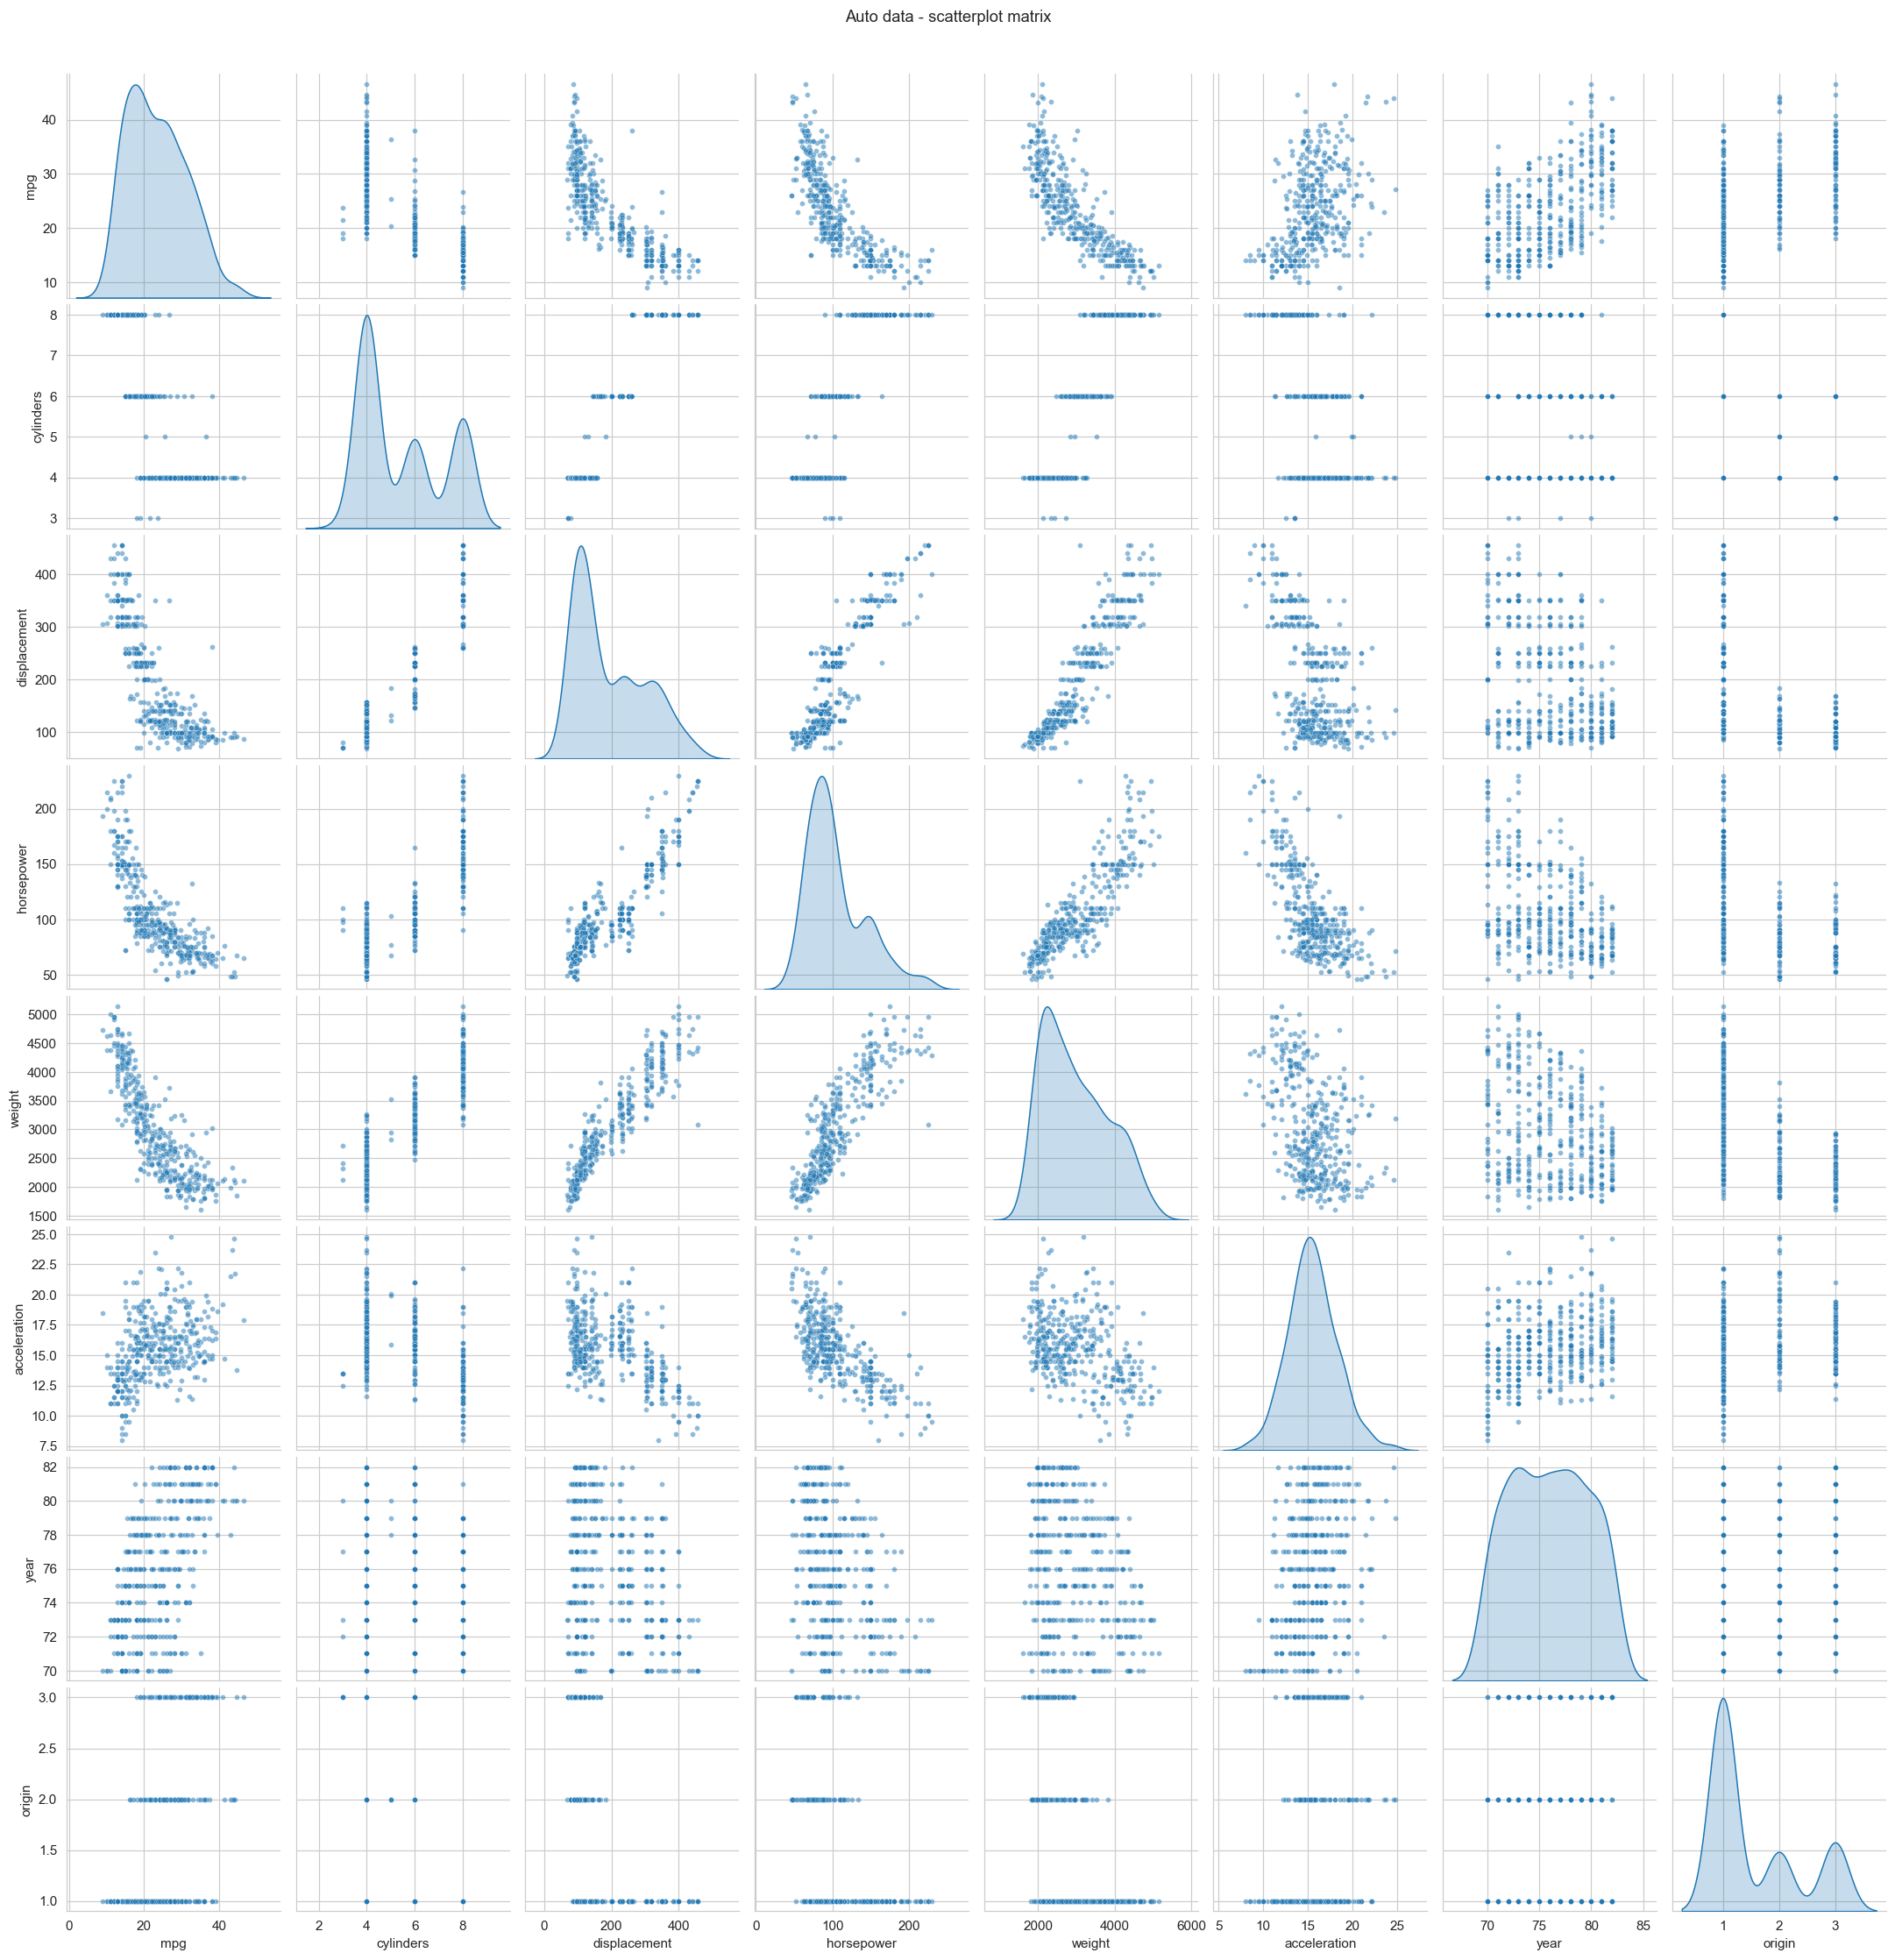

In [9]:
sns.pairplot(auto.drop(columns=['name']), diag_kind='kde', plot_kws={'s': 15, 'alpha': 0.5})
plt.suptitle('Auto data - scatterplot matrix', y=1.02)
plt.show()

Comment (a): mpg is negatively related to cylinders, displacement, horsepower
and weight, and positively related to acceleration and year. The strongest linear
associations with mpg are weight and displacement.

### (b) Correlation matrix

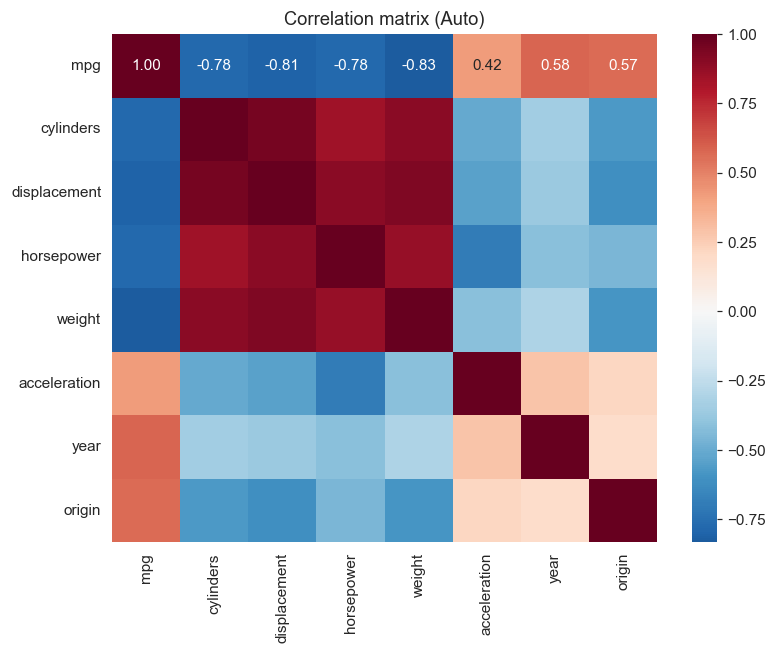

In [10]:
corr = auto.drop(columns=['name']).corr()
corr.round(3)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Correlation matrix (Auto)')
plt.show()

Comment (b): mpg correlates strongly and negatively with weight (-0.83),
displacement (-0.81) and horsepower (-0.78), and strongly positively with year (0.58).
Many predictors are highly correlated with each other (e.g. displacement, horsepower,
weight), which can cause collinearity issues in multiple regression.

### (c) Multiple linear regression: mpg ~ all predictors except name

In [11]:
# origin is treated as a numeric variable (1=American, 2=European, 3=Japanese),
# exactly as in the textbook's analysis (Table 3.4).
auto2 = auto.copy()
Xm = auto2.drop(columns=['mpg', 'name']).astype(float)
Xm = sm.add_constant(Xm)
y = auto2['mpg']

model_c = sm.OLS(y, Xm).fit()
print(model_c.summary())

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.821
Model:                            OLS   Adj. R-squared:                  0.818
Method:                 Least Squares   F-statistic:                     252.4
Date:                Fri, 02 Oct 2026   Prob (F-statistic):          2.04e-139
Time:                        03:50:40   Log-Likelihood:                -1023.5
No. Observations:                 392   AIC:                             2063.
Df Residuals:                     384   BIC:                             2095.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -17.2184      4.644     -3.707   

Answers (c):
- i. Is there a relationship? Yes. The F-statistic is very large and its p-value is
  essentially 0, so we reject H0: all regression coefficients are zero. The R^2 is about 0.82.
- ii. Statistically significant predictors (p < 0.05): displacement, weight, year
  and origin. Cylinders, horsepower and acceleration are not significant at the 5%
  level after adjusting for the other variables.
- iii. The coefficient for year is about +0.75: holding all other variables fixed, a car
  made one year later has on average about 0.75 higher mpg, i.e. cars have become steadily
  more fuel-efficient over time.

In [12]:
# Print the significant predictors explicitly
pvals = model_c.pvalues
sig = pvals[(pvals < 0.05) & (pvals.index != 'const')]
print('Predictors significant at 5% level:')
print(sig)

Predictors significant at 5% level:
displacement    8.444649e-03
weight          7.874953e-21
year            3.055983e-39
origin          4.665681e-07
dtype: float64


### (d) Diagnostic plots

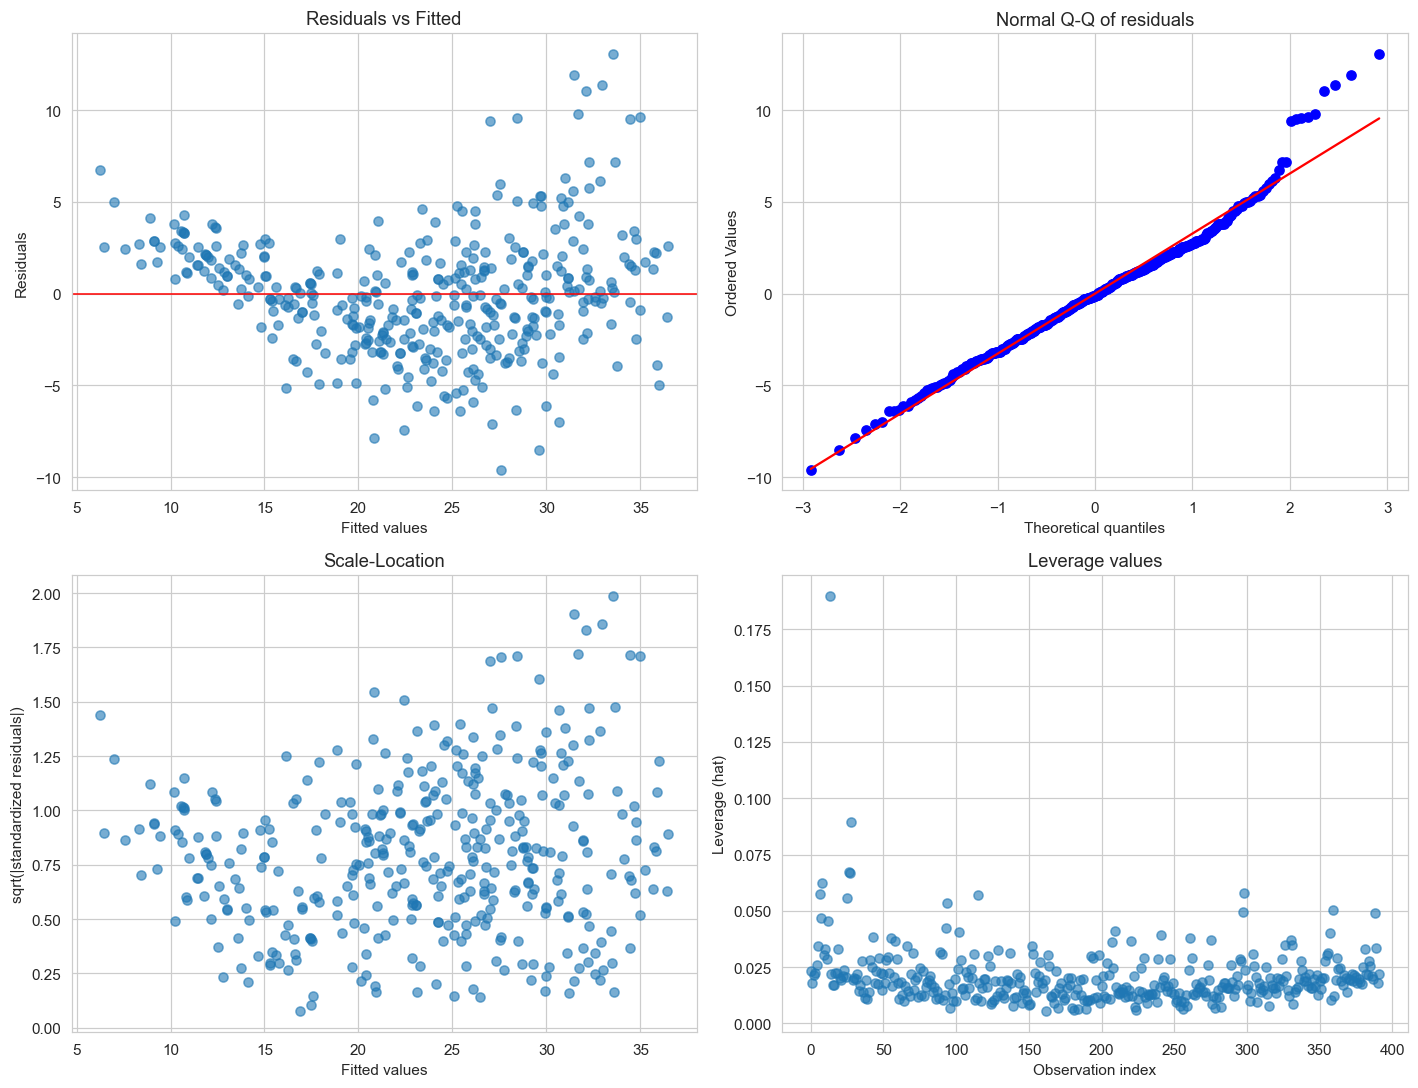

In [13]:
infl = OLSInfluence(model_c)
fitted = model_c.fittedvalues
resid = model_c.resid
stud_resid = infl.resid_studentized_internal

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

axes[0, 0].scatter(fitted, resid, alpha=0.6)
axes[0, 0].axhline(0, color='red', lw=1)
axes[0, 0].set_xlabel('Fitted values'); axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Fitted')

stats.probplot(resid, dist='norm', plot=axes[0, 1])
axes[0, 1].set_title('Normal Q-Q of residuals')

axes[1, 0].scatter(fitted, np.sqrt(np.abs(stud_resid)), alpha=0.6)
axes[1, 0].set_xlabel('Fitted values'); axes[1, 0].set_ylabel('sqrt(|standardized residuals|)')
axes[1, 0].set_title('Scale-Location')

hat = infl.hat_matrix_diag
axes[1, 1].scatter(np.arange(len(hat)), hat, alpha=0.6)
axes[1, 1].set_xlabel('Observation index'); axes[1, 1].set_ylabel('Leverage (hat)')
axes[1, 1].set_title('Leverage values')

plt.tight_layout()
plt.show()

Comment (d): The residual vs fitted plot shows a clear curved (non-linear) pattern
rather than a random cloud, suggesting that a purely linear model underfits the data.
The Q-Q plot shows heavy tails at the extremes (a few large positive residuals).
The scale-location plot shows increasing spread with fitted values (heteroscedasticity).
A few observations have very high leverage; together these diagnostics suggest trying
interactions and transformations (parts e and f).

### (e) Interaction effects

In [14]:
preds = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'year', 'origin']

from itertools import combinations
num_preds = preds
Xint = auto2[preds].copy().astype(float)
for a, b in combinations(num_preds, 2):
    Xint[f'{a}:{b}'] = auto2[a] * auto2[b]
Xint = sm.add_constant(Xint)

model_e = sm.OLS(y, Xint).fit()
inter_cols = [c for c in Xint.columns if ':' in c]
sig_inter = model_e.pvalues[inter_cols][model_e.pvalues[inter_cols] < 0.05]
print('Statistically significant interaction terms (p < 0.05):')
print(sig_inter.sort_values())

Statistically significant interaction terms (p < 0.05):
acceleration:origin    0.003655
displacement:year      0.013516
acceleration:year      0.030331
dtype: float64


Comment (e): A number of pairwise interaction terms are statistically significant
(printed above), most notably acceleration:origin, displacement:year and acceleration:year.
This confirms that the effect of one predictor on mpg depends on the values of other
predictors, so a purely additive model (c) is not fully adequate.

### (f) Transformations

In [15]:
def fit_ols(preds_list, label='model'):
    Xf = sm.add_constant(auto2[preds_list].astype(float))
    m = sm.OLS(y, Xf).fit()
    print(f'{label}: R^2 = {m.rsquared:.4f}, adj R^2 = {m.rsquared_adj:.4f}, AIC = {m.aic:.1f}')
    return m

base_preds = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'year', 'origin']
fit_ols(base_preds, 'M0 baseline linear      ')

for tname, trans in [('log', np.log), ('sqrt', np.sqrt), ('square', lambda x: x**2)]:
    tp = base_preds + [f'{tname}_{p}' for p in ['displacement', 'horsepower', 'weight']]
    auto2[f'{tname}_displacement'] = trans(auto2['displacement'])
    auto2[f'{tname}_horsepower'] = trans(auto2['horsepower'])
    auto2[f'{tname}_weight'] = trans(auto2['weight'])
    fit_ols(tp, f'M1 {tname} on disp/hp/weight')

M0 baseline linear      : R^2 = 0.8215, adj R^2 = 0.8182, AIC = 2062.9
M1 log on disp/hp/weight: R^2 = 0.8643, adj R^2 = 0.8607, AIC = 1961.4
M1 sqrt on disp/hp/weight: R^2 = 0.8650, adj R^2 = 0.8614, AIC = 1959.5
M1 square on disp/hp/weight: R^2 = 0.8653, adj R^2 = 0.8618, AIC = 1958.5


Comment (f): Transforming displacement, horsepower and weight (log, sqrt or square)
improves the fit slightly (higher R^2 and lower AIC than the baseline linear model),
confirming that some non-linear relationships exist. The log transformation gives a
modest improvement over the plain linear model.

## 3. Extra Practice (not submitted): ISLR 3.7.3, 3.7.5

Per the assignment, the answers to ISLR 3.7.3 and 3.7.5 are extra practice and
are NOT required for submission, so they are omitted here.

References
- AReM data: https://archive.ics.uci.edu/ml/datasets/Activity+Recognition+system+based+on+Multisensor+data+fusion+(AReM)
- ISLR Auto data: https://www.statlearning.com/s/Auto.csv
- James, Witten, Hastie, Tibshirani, An Introduction to Statistical Learning (2nd ed.)